In [2]:
import pandas as pd 

users_df = pd.read_csv("../data1/users_clean.csv") 
books_df = pd.read_csv("../data1/books_clean.csv")
orders_df = pd.read_csv("../data1/orders_clean.csv")

In [3]:
daily_revenue = orders_df.groupby('date')['paid_price'].sum().reset_index()
daily_revenue.columns = ['date', 'revenue']
top5 = daily_revenue.nlargest(5, 'revenue')
print(top5)

                    date  revenue
415  2025-01-02 00:00:00  3993.25
349  2024-11-14 00:00:00  3908.42
243  2024-09-06 00:00:00  3786.21
342  2024-11-09 00:00:00  3497.33
287  2024-10-07 00:00:00  3455.62


In [4]:
parent = {i: i for i in users_df.index}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    parent[find(x)] = find(y)

def is_same_user(r1, r2):
    matches = (
        (r1['name'] == r2['name']) +
        (r1['address'] == r2['address']) +
        (r1['phone'] == r2['phone']) +
        (r1['email'] == r2['email'])
    )
    return matches >= 3

records = users_df.reset_index().to_dict('records')

for i in range(len(records)):
    for j in range(i + 1, len(records)):
        if is_same_user(records[i], records[j]):
            union(records[i]['index'], records[j]['index'])

unique_users = len(set(find(i) for i in users_df.index))
print(f"Real unique users: {unique_users}")

Real unique users: 3115


In [5]:
books_df['author'].nunique()

374

In [6]:
most_popular = orders_df.groupby('book_id')['quantity'].sum().reset_index()
merged = orders_df.merge(books_df, left_on='book_id', right_on='id')
author_sales = merged.groupby('author')['quantity'].sum().reset_index()
author_sales.columns = ['author', 'total_sold']
most_popular = author_sales.nlargest(1, 'total_sold')
print(most_popular)

          author  total_sold
35  Arlinda Huel         201


In [7]:

users_df['user_group'] = [find(i) for i in users_df.index]


merged = orders_df.merge(users_df[['id', 'user_group']], left_on='user_id', right_on='id')

spending = merged.groupby('user_group')['paid_price'].sum().reset_index()
spending.columns = ['user_group', 'total_spent']


top_group = spending.nlargest(1, 'total_spent')['user_group'].values[0]
print(f"Top spending group: {top_group}, Total: {spending[spending['user_group'] == top_group]['total_spent'].values[0]}")

all_ids = users_df[users_df['user_group'] == top_group]
print(all_ids[['id', 'name', 'email', 'phone', 'address']])

Top spending group: 2228, Total: 1382.48
         id                name                            email       phone  \
373   45062  Rev. Johnson Olson  jorge@hartmann-medhurst.example  1494070465   
1327  46955       Yukiko Becker  jorge@hartmann-medhurst.example  4438931024   
2228  44850       Yukiko Becker  jorge@hartmann-medhurst.example  1494070465   

                                                address  
373   Apt. 245 5042 Annette Islands, South Andrevill...  
1327  Apt. 245 5042 Annette Islands, South Andrevill...  
2228  Apt. 245 5042 Annette Islands, South Andrevill...  


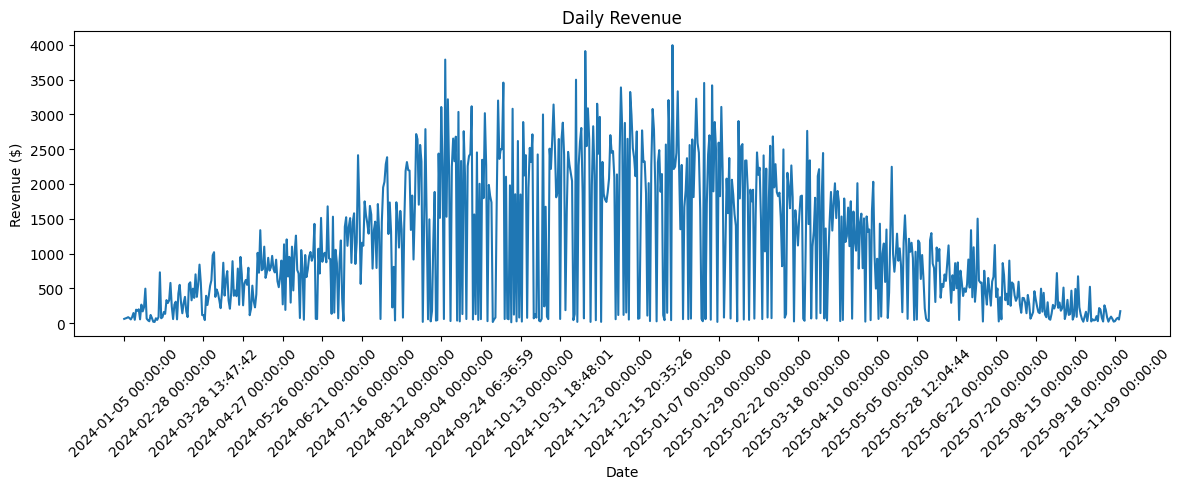

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(daily_revenue['date'], daily_revenue['revenue'])
plt.title('Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.xticks(daily_revenue['date'][::30], rotation=45)  
plt.tight_layout()
plt.show()